# Данный ноубук Выполняет предварительную обработку данных (часть 1). Выполняет обучение модели  DenceNet-121 (часть 2).

In [1]:
!pip install kagglehub 


[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import kagglehub

# скачиваем последнюю версию
path = kagglehub.dataset_download("nih-chest-xrays/data")

print(path)

In [ ]:
import pandas as pd
import os
import glob

def create_master_csv_nested(data_root_dir, output_csv='nih_master_data.csv'):
    """
    Создает единый CSV-файл для вложенной структуры:
    data_root_dir/
        images_001/
            images/  ← PNG файлы здесь
        images_002/
            images/  ← PNG файлы здесь
        ...
    """
    
    print(f"Начинаем обработку данных в: {data_root_dir}")
    print("=" * 60)
    
    # 1. Загружаем метки
    labels_path = os.path.join(data_root_dir, 'Data_Entry_2017.csv')
    if not os.path.exists(labels_path):
        print(f"Файл меток не найден: {labels_path}")
        return None
    
    labels_df = pd.read_csv(labels_path)
    print(f"Загружено {len(labels_df)} записей из Data_Entry_2017.csv")
    
    # 2. Ищем все PNG файлы по новой структуре
    # Ищем во всех папках images_*/images/*.png
    all_image_paths = []
    
    # Находим все папки images_001, images_002, ..., images_012
    for i in range(1, 13):
        folder_name = f"images_{i:03d}"
        folder_path = os.path.join(data_root_dir, folder_name, 'images')
        
        if os.path.exists(folder_path):
            # Ищем PNG файлы в этой папке
            png_files = glob.glob(os.path.join(folder_path, "*.png"))
            all_image_paths.extend(png_files)
            
            if i <= 3:  # Покажем для первых 3 папок
                print(f"    {folder_name}/images/: {len(png_files)} PNG")
        else:
            print(f"     Папка не найдена: {folder_path}")
    
    print(f"Всего найдено PNG файлов: {len(all_image_paths)}")
    
    if len(all_image_paths) == 0:
        print("Не найдено ни одного PNG файла!")
        print("   Проверьте структуру папок.")
        return None
    
    # 3. Создаем словарь: имя_файла -> полный_путь
    path_dict = {}
    for img_path in all_image_paths:
        filename = os.path.basename(img_path)  # '00000001_000.png'
        path_dict[filename] = img_path
    
    # 4. Добавляем пути к меткам
    labels_df['full_path'] = labels_df['Image Index'].map(path_dict)
    
    # 5. Проверяем сколько файлов нашлось
    found_count = labels_df['full_path'].notna().sum()
    missing_count = len(labels_df) - found_count
    
    print(f"\n Соответствие меток и файлов:")
    print(f"    Найдено: {found_count}")
    print(f"    Отсутствует: {missing_count}")
    
    if missing_count > 0:
        print("\n   Примеры отсутствующих файлов:")
        missing_samples = labels_df[labels_df['full_path'].isna()]['Image Index'].head(3).tolist()
        for sample in missing_samples:
            print(f"      - {sample}")
    
    # 6. Удаляем записи без файлов
    labels_df = labels_df.dropna(subset=['full_path'])
    print(f"\n После очистки осталось: {len(labels_df)} записей")
    
    # 7. Создаем one-hot encoding для заболеваний
    print("\n🏷  Создаем one-hot encoding меток...")
    
    # Получаем все уникальные заболевания
    all_labels = []
    for label_str in labels_df['Finding Labels'].astype(str):
        all_labels.extend(label_str.split('|'))
    
    unique_diseases = sorted(set(all_labels))
    print(f"   Уникальных заболеваний: {len(unique_diseases)}")
    print(f"   {unique_diseases}")
    
    # Создаем бинарные столбцы
    for disease in unique_diseases:
        labels_df[disease] = labels_df['Finding Labels'].apply(
            lambda x: 1 if disease in str(x).split('|') else 0
        )
    
    # 8. Сохраняем результат
    output_path = os.path.join(data_root_dir, output_csv)
    labels_df.to_csv(output_path, index=False)
    
    print("\n" + "=" * 60)
    print(f" МАСТЕР-ФАЙЛ СОЗДАН: {output_csv}")
    print(f" Статистика:")
    print(f"   • Всего записей: {len(labels_df)}")
    print(f"   • Всего заболеваний: {len(unique_diseases)}")
    
    # Показываем пример структуры
    if len(labels_df) > 0:
        example = labels_df.iloc[0]
        print(f"\n Пример записи:")
        print(f"   Файл: {example['Image Index']}")
        print(f"   Метки: {example['Finding Labels']}")
        # Показываем только конец пути (чтобы не загромождать)
        short_path = '...' + example['full_path'][-80:] if len(example['full_path']) > 80 else example['full_path']
        print(f"   Путь: {short_path}")
    
    return labels_df, unique_diseases


data_root = "3"  # путь к папке с данными

# Запускаем
print(" ЗАПУСК ОБРАБОТКИ ДАННЫХ NIH CHEST X-RAYS")
print("=" * 60)
master_df, diseases_list = create_master_csv_nested(data_root)

In [ ]:
master_df

In [ ]:
diseases_list

# Код в строке ниже запускаем что бы не повторять пересборку master_df а загружаем данные уже из сформированого csv файла

In [7]:
import pandas as pd

diseases_list = ['Atelectasis',
 'Cardiomegaly',
 'Consolidation',
 'Edema',
 'Effusion',
 'Emphysema',
 'Fibrosis',
 'Hernia',
 'Infiltration',
 'Mass',
 'No Finding',
 'Nodule',
 'Pleural_Thickening',
 'Pneumonia',
 'Pneumothorax']

master_df = pd.read_csv("3\\nih_master_data.csv")

Разбиваем выборку на тестовую и валидационную

In [4]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Разделяем данные на train и test (85%/15%)
train_df, test_df = train_test_split(
    master_df,
    test_size=0.15,
    random_state=42,
    stratify=master_df['No Finding']  # балансируем по классу No Finding
)

print(f"Train размер: {len(train_df)} записей")
print(f"Test размер: {len(test_df)} записей")

# Сохраняем в файлы
train_df.to_csv('3\\train_data.csv', index=False)
test_df.to_csv('3\\test_data.csv', index=False)

print("Файлы сохранены:")
print("- 3\\train_data.csv")
print("- 3\\test_data.csv")

Train размер: 95302 записей
Test размер: 16818 записей
Файлы сохранены:
- 3\train_data.csv
- 3\test_data.csv


# Ячейку ниже запускаем что бы не повторять перезборку тренировочной и тестовой выборок

In [9]:
import pandas as pd
train_df = pd.read_csv("3\\train_data.csv")
test_df = pd.read_csv("3\\test_data.csv")

# Анализируем данные

график для всех наблюдений

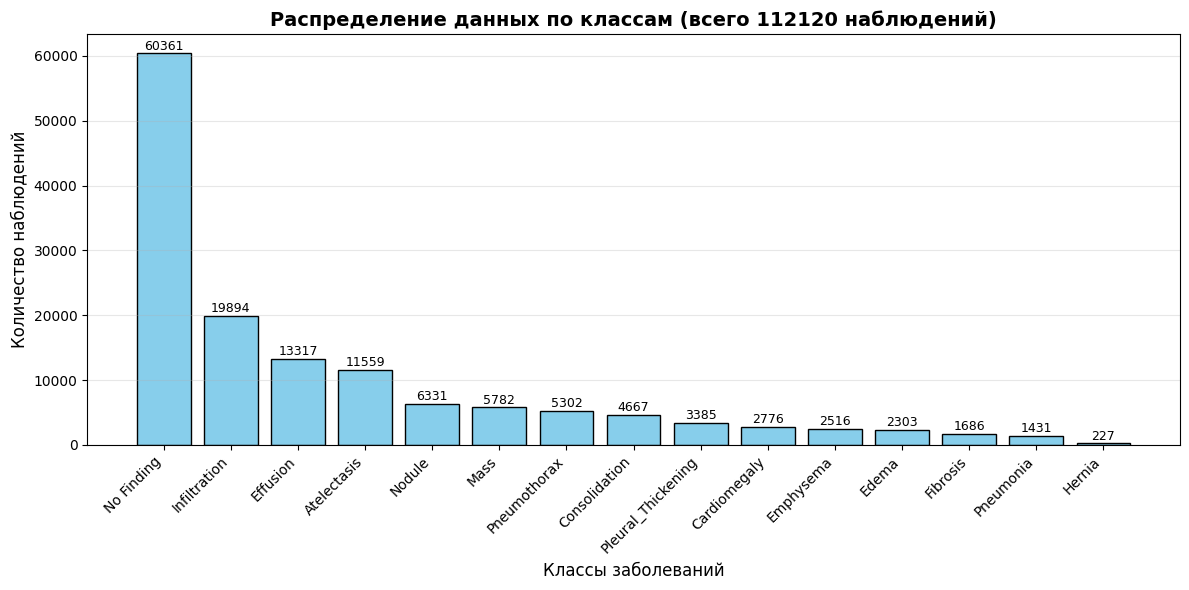

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Сортируем данные по убыванию
disease_counts = master_df[diseases_list].sum()
disease_counts_sorted = disease_counts.sort_values(ascending=False)

# Подготовим данные для диаграммы
disease_names = disease_counts_sorted.index.tolist()
counts = disease_counts_sorted.values.tolist()

# Создаем вертикальную столбчатую диаграмму
plt.figure(figsize=(12, 6))
bars = plt.bar(disease_names, counts, color='skyblue', edgecolor='black')

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.title('Распределение данных по классам (всего {} наблюдений)'.format(len(master_df)), fontsize=14, fontweight='bold')
plt.xlabel('Классы заболеваний', fontsize=12)
plt.ylabel('Количество наблюдений', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

In [8]:
# Получаем статистику по всем классам
disease_stats = master_df[diseases_list].sum().sort_values(ascending=False)

# Выводим статистику
print("СТАТИСТИКА ПО КЛАССАМ (ВСЕ НАБЛЮДЕНИЯ):")
print("=" * 50)
print(f"Всего наблюдений: {len(master_df)}")
print("=" * 50)

for disease, count in disease_stats.items():
    percentage = (count / len(master_df)) * 100
    print(f"{disease:20s}: {count:6d} ({percentage:6.2f}%)")

print("=" * 50)

СТАТИСТИКА ПО КЛАССАМ (ВСЕ НАБЛЮДЕНИЯ):
Всего наблюдений: 112120
No Finding          :  60361 ( 53.84%)
Infiltration        :  19894 ( 17.74%)
Effusion            :  13317 ( 11.88%)
Atelectasis         :  11559 ( 10.31%)
Nodule              :   6331 (  5.65%)
Mass                :   5782 (  5.16%)
Pneumothorax        :   5302 (  4.73%)
Consolidation       :   4667 (  4.16%)
Pleural_Thickening  :   3385 (  3.02%)
Cardiomegaly        :   2776 (  2.48%)
Emphysema           :   2516 (  2.24%)
Edema               :   2303 (  2.05%)
Fibrosis            :   1686 (  1.50%)
Pneumonia           :   1431 (  1.28%)
Hernia              :    227 (  0.20%)


график для тренировочной выборки

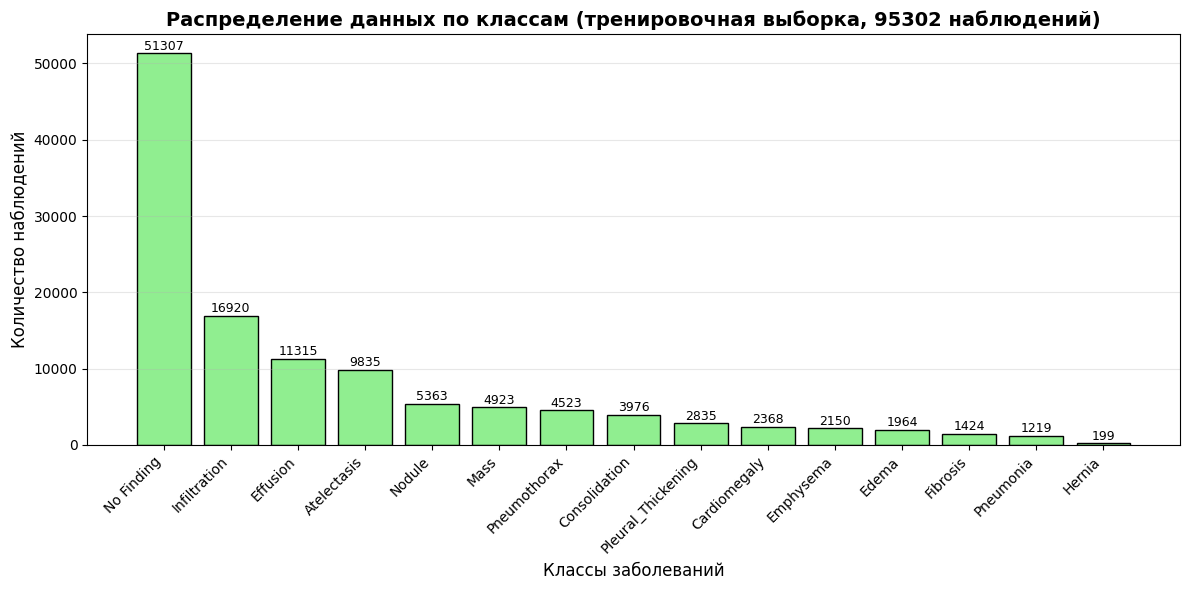

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Сортируем данные тренировочной выборки по убыванию
disease_counts_train = train_df[diseases_list].sum()
disease_counts_train_sorted = disease_counts_train.sort_values(ascending=False)

# Подготовим данные для диаграммы
disease_names = disease_counts_train_sorted.index.tolist()
counts = disease_counts_train_sorted.values.tolist()

# Создаем вертикальную столбчатую диаграмму
plt.figure(figsize=(12, 6))
bars = plt.bar(disease_names, counts, color='lightgreen', edgecolor='black')

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 80,
             f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.title('Распределение данных по классам (тренировочная выборка, {} наблюдений)'.format(len(train_df)), 
          fontsize=14, fontweight='bold')
plt.xlabel('Классы заболеваний', fontsize=12)
plt.ylabel('Количество наблюдений', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

In [9]:
# Получаем статистику по тренировочной выборке
disease_stats_train = train_df[diseases_list].sum().sort_values(ascending=False)

# Выводим статистику
print("СТАТИСТИКА ПО КЛАССАМ (ТРЕНИРОВОЧНАЯ ВЫБОРКА):")
print("=" * 50)
print(f"Всего наблюдений: {len(train_df)}")
print("=" * 50)

for disease, count in disease_stats_train.items():
    percentage = (count / len(train_df)) * 100
    print(f"{disease:20s}: {count:6d} ({percentage:6.2f}%)")

print("=" * 50)

СТАТИСТИКА ПО КЛАССАМ (ТРЕНИРОВОЧНАЯ ВЫБОРКА):
Всего наблюдений: 95302
No Finding          :  51307 ( 53.84%)
Infiltration        :  16920 ( 17.75%)
Effusion            :  11315 ( 11.87%)
Atelectasis         :   9835 ( 10.32%)
Nodule              :   5363 (  5.63%)
Mass                :   4923 (  5.17%)
Pneumothorax        :   4523 (  4.75%)
Consolidation       :   3976 (  4.17%)
Pleural_Thickening  :   2835 (  2.97%)
Cardiomegaly        :   2368 (  2.48%)
Emphysema           :   2150 (  2.26%)
Edema               :   1964 (  2.06%)
Fibrosis            :   1424 (  1.49%)
Pneumonia           :   1219 (  1.28%)
Hernia              :    199 (  0.21%)


# Расчет весов для классов в связи с дисбалансом классов

In [10]:
import numpy as np

# 1. Рассчитать веса классов на тренировочной выборке
class_counts = train_df[diseases_list].sum().values

# 2. Вычислить веса (обратно пропорционально частоте)
class_weights = np.sqrt(np.max(class_counts) / class_counts)

# 3. Сохранить веса
np.save('3/class_weights.npy', class_weights)

print(" Веса классов сохранены в 'class_weights.npy'")
print("\nВеса для каждого класса:")
for cls, weight in zip(diseases_list, class_weights):
    count = train_df[cls].sum()
    print(f"  {cls:<25} count: {count:6d}, weight: {weight:.4f}")

✅ Веса классов сохранены в 'class_weights.npy'

Веса для каждого класса:
  Atelectasis               count:   9835, weight: 2.2840
  Cardiomegaly              count:   2368, weight: 4.6548
  Consolidation             count:   3976, weight: 3.5922
  Edema                     count:   1964, weight: 5.1111
  Effusion                  count:  11315, weight: 2.1294
  Emphysema                 count:   2150, weight: 4.8851
  Fibrosis                  count:   1424, weight: 6.0025
  Hernia                    count:    199, weight: 16.0569
  Infiltration              count:  16920, weight: 1.7414
  Mass                      count:   4923, weight: 3.2283
  No Finding                count:  51307, weight: 1.0000
  Nodule                    count:   5363, weight: 3.0930
  Pleural_Thickening        count:   2835, weight: 4.2541
  Pneumonia                 count:   1219, weight: 6.4876
  Pneumothorax              count:   4523, weight: 3.3680


Проверяем размер изображений

In [11]:
from PIL import Image
sample_path = train_df.iloc[0]['full_path']
img = Image.open(sample_path)
print(f"РАЗМЕР ИЗОБРАЖЕНИЙ:")
print(f"Пример: {img.size} (будет изменен на 224×224)")

РАЗМЕР ИЗОБРАЖЕНИЙ:
Пример: (1024, 1024) (будет изменен на 224×224)


# Обучение моделей

# расбивка тренировочной выборки алгоритмом Бутстрап (Bootstrap)

In [14]:
import numpy as np
import pandas as pd

def create_bootstrap_datasets_85_15(train_df, n_datasets=3, random_state=42):
    """
    Создает n_datasets бутстрап выборок с разделением 85%/15%
    (85% - train, 15% - val из неиспользованных данных)
    
    Parameters:
    -----------
    train_df : DataFrame
        Исходная тренировочная выборка
    n_datasets : int
        Количество бутстрап выборок
    random_state : int
        Seed для воспроизводимости
    
    Returns:
    --------
    train_datasets : list of DataFrames
        Список бутстрап выборок для обучения (85%)
    val_datasets : list of DataFrames
        Список валидационных выборок (15%)
    """
    
    train_datasets = []
    val_datasets = []
    
    print(f"Создаем {n_datasets} пар (85% train / 15% val)")
    print(f"Исходный размер тренировочной выборки: {len(train_df)}")
    print("-" * 50)
    
    # Рассчитываем размеры
    train_size = int(len(train_df) * 0.85)
    val_size = len(train_df) - train_size
    
    for i in range(n_datasets):
        # 1. Создаем бутстрап выборку на 85% данных
        np.random.seed(random_state + i)
        
        # Бутстрап с заменой для 85% данных
        bootstrap_sample = train_df.sample(
            n=train_size,
            replace=True,
            random_state=random_state + i,
            weights=train_df['No Finding'].apply(lambda x: 0.8 if x == 1 else 1.2)  # балансировка
        )
        
        # 2. Получаем индексы, которые не попали в бутстрап
        bootstrap_indices = set(bootstrap_sample.index)
        all_indices = set(train_df.index)
        unused_indices = list(all_indices - bootstrap_indices)
        
        # 3. Берем 15% данных из неиспользованных
        if len(unused_indices) >= val_size:
            val_sample = train_df.loc[unused_indices].sample(
                n=val_size,
                random_state=random_state + i + 1000
            )
        else:
            # Если неиспользованных недостаточно, берем часть из бутстрап
            val_from_unused = train_df.loc[unused_indices]
            val_from_bootstrap = train_df.loc[list(bootstrap_indices)].sample(
                n=val_size - len(val_from_unused),
                random_state=random_state + i + 1000
            )
            val_sample = pd.concat([val_from_unused, val_from_bootstrap])
            # Убираем валидационные данные из обучающей выборки
            bootstrap_sample = bootstrap_sample[~bootstrap_sample.index.isin(val_from_bootstrap.index)]
        
        train_datasets.append(bootstrap_sample)
        val_datasets.append(val_sample)
        
        print(f"Выборка {i+1}:")
        print(f"  • Train: {len(bootstrap_sample)} записей ({len(bootstrap_sample)/len(train_df)*100:.1f}%)")
        print(f"  • Val: {len(val_sample)} записей ({len(val_sample)/len(train_df)*100:.1f}%)")
        
        # Пересечение между train и val
        train_val_intersection = len(set(bootstrap_sample['Image Index']) & set(val_sample['Image Index']))
        print(f"  • Пересечение изображений в train/val: {train_val_intersection} ({(train_val_intersection/len(bootstrap_sample)*100):.1f}%)")
        
        # Статистика по No Finding
        print(f"  • No Finding в train: {(bootstrap_sample['No Finding'] == 1).sum()/len(bootstrap_sample)*100:.1f}%")
        print(f"  • No Finding в val: {(val_sample['No Finding'] == 1).sum()/len(val_sample)*100:.1f}%")
        print()
    
    # Проверяем пересечение между разными выборками
    print("=" * 50)
    print("ПЕРЕСЕЧЕНИЕ МЕЖДУ РАЗНЫМИ ВЫБОРКАМИ (train выборки):")
    
    for i in range(n_datasets):
        for j in range(i+1, n_datasets):
            set_i = set(train_datasets[i]['Image Index'])
            set_j = set(train_datasets[j]['Image Index'])
            intersection = set_i.intersection(set_j)
            
            print(f"  Train {i+1} и {j+1}: {len(intersection)} общих изображений ({len(intersection)/len(set_i)*100:.1f}%)")
    
    return train_datasets, val_datasets

# Создаем 3 пары train/val выборок
print(" СОЗДАНИЕ БУТСТРАП ВЫБОРОК 85%/15%")
print("=" * 60)

train_datasets, val_datasets = create_bootstrap_datasets_85_15(
    train_df,
    n_datasets=3,
    random_state=42
)

# Сохраняем выборки
print("\n СОХРАНЕНИЕ ВЫБОРОК")
for i in range(len(train_datasets)):
    train_filename = f'bootstrap_train_{i+1}.csv'
    val_filename = f'bootstrap_val_{i+1}.csv'
    
    train_datasets[i].to_csv(train_filename, index=False)
    val_datasets[i].to_csv(val_filename, index=False)
    
    print(f"  • {train_filename}: {len(train_datasets[i])} записей")
    print(f"  • {val_filename}: {len(val_datasets[i])} записей")
    print()

print(" ГОТОВО! Для каждой нейросети:")
print(f"  - Обучающая выборка: ~{len(train_datasets[0])} записей (~85%)")
print(f"  - Валидационная выборка: ~{len(val_datasets[0])} записей (~15%)")
print(f"  - Общий размер сохраняется: ~{len(train_datasets[0]) + len(val_datasets[0])} записей")

🚀 СОЗДАНИЕ БУТСТРАП ВЫБОРОК 85%/15%
Создаем 3 пар (85% train / 15% val)
Исходный размер тренировочной выборки: 95302
--------------------------------------------------
Выборка 1:
  • Train: 81006 записей (85.0%)
  • Val: 14296 записей (15.0%)
  • Пересечение изображений в train/val: 0 (0.0%)
  • No Finding в train: 43.7%
  • No Finding в val: 62.0%

Выборка 2:
  • Train: 81006 записей (85.0%)
  • Val: 14296 записей (15.0%)
  • Пересечение изображений в train/val: 0 (0.0%)
  • No Finding в train: 44.0%
  • No Finding в val: 62.4%

Выборка 3:
  • Train: 81006 записей (85.0%)
  • Val: 14296 записей (15.0%)
  • Пересечение изображений в train/val: 0 (0.0%)
  • No Finding в train: 44.0%
  • No Finding в val: 62.0%

ПЕРЕСЕЧЕНИЕ МЕЖДУ РАЗНЫМИ ВЫБОРКАМИ (train выборки):
  Train 1 и 2: 31018 общих изображений (57.5%)
  Train 1 и 3: 31106 общих изображений (57.7%)
  Train 2 и 3: 30970 общих изображений (57.4%)

💾 СОХРАНЕНИЕ ВЫБОРОК
  • bootstrap_train_1.csv: 81006 записей
  • bootstrap_val_1.csv

# Загрузка тренировочной и валидационной выборок для обучения первой нейросети

In [ ]:
import pandas as pd

bootstrap_train_1 = pd.read_csv('bootstrap_train_1.csv')
bootstrap_val_1 = pd.read_csv('bootstrap_val_1.csv')

# Формирование модели и начало обучения

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np

# 1. Определяем кастомный Dataset
class ChestXrayDataset(Dataset):
    def __init__(self, csv_file, disease_columns, transform=None):
        self.data = pd.read_csv(csv_file)
        self.disease_columns = disease_columns
        self.transform = transform
        
        if transform is None:
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], 
                                     [0.229, 0.224, 0.225])
            ])
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_path = self.data.iloc[idx]['full_path']
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        labels = self.data.iloc[idx][self.disease_columns].values
        labels = torch.tensor(labels.astype(np.float32))
        
        return image, labels

# 2. Создаем трансформации
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. Создаем Dataset объекты
train_dataset_1 = ChestXrayDataset(
    csv_file='bootstrap_train_1.csv',
    disease_columns=diseases_list,
    transform=train_transform
)

val_dataset_1 = ChestXrayDataset(
    csv_file='bootstrap_val_1.csv', 
    disease_columns=diseases_list,
    transform=val_transform
)

In [3]:
import torch
print(f"PyTorch версия: {torch.__version__}")
print(f"CUDA доступна в PyTorch: {torch.cuda.is_available()}")

PyTorch версия: 2.7.1+cu118
CUDA доступна в PyTorch: True


In [4]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.7.1+cu118
CUDA available: True
CUDA version: 11.8
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


# Задаем параметры обучения DenceNet-121

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import models, transforms
import numpy as np

# Загружаем веса классов
class_weights = np.load('3//class_weights.npy')
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

#  Определяем Weighted Focal Loss
class WeightedFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, weight=None, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        BCE_loss = nn.functional.binary_cross_entropy_with_logits(
            inputs, targets, reduction='none'
        )
        
        pt = torch.exp(-BCE_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
        
        if self.weight is not None:
            # Умножаем на веса классов
            weight_tensor = self.weight.to(inputs.device)
            # Для multi-label: усредняем веса активных классов
            active_weights = targets * weight_tensor.unsqueeze(0)
            weight_sum = active_weights.sum(dim=1)
            focal_loss = focal_loss * weight_sum.unsqueeze(1)
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

#  Модифицируем DenseNet-121
def get_densenet121(num_classes=15, dropout_rate=0.5):
    model = models.densenet121(pretrained=True)
    
    # Замораживаем начальные слои
    for param in model.features.parameters():
        param.requires_grad = False
    
    # Модифицируем классификатор
    in_features = model.classifier.in_features
    
    # Новый классификатор с L2 регуляризацией в слоях
    model.classifier = nn.Sequential(
        nn.Dropout(dropout_rate),
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512, momentum=0.99),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout_rate/2),
        nn.Linear(512, 256),
        nn.BatchNorm1d(256, momentum=0.99),
        nn.ReLU(inplace=True),
        nn.Linear(256, num_classes)
    )
    
    # Инициализируем веса новых слоев
    for m in model.classifier.modules():
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
    
    return model

#  Обновленные аугментации
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomAffine(
        degrees=15,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

#  Создаем модель
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = get_densenet121(num_classes=len(diseases_list), dropout_rate=0.5).to(device)

#  Оптимизатор с L2 регуляризацией
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    betas=(0.9, 0.999),  # Изменено с (0., 0.999) на стандартные значения
    weight_decay=1e-5
)

#  Функция потерь
criterion = WeightedFocalLoss(
    alpha=0.25,
    gamma=2.0,
    weight=class_weights_tensor
)

#  Schedulers
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=3,
    #verbose=True,
    min_lr=1e-6
)

#  DataLoader
batch_size = 32
train_loader = DataLoader(
    train_dataset_1,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0, # было 4
    pin_memory=True,
    drop_last=True  # Для стабильной batch norm
)

val_loader = DataLoader(
    val_dataset_1,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0, # было 2
    pin_memory=True
)

print(" Все готово для обучения DenseNet-121")
print(f"   Устройство: {device}")
print(f"   Классов: {len(diseases_list)}")
print(f"   Batch size: {batch_size}")
print(f"   Learning rate: {optimizer.param_groups[0]['lr']}")

C:\python\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\python\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ Все готово для обучения DenseNet-121
   Устройство: cuda
   Классов: 15
   Batch size: 32
   Learning rate: 0.0001


# обучаем модель DenceNet-121

In [7]:
import time
from tqdm.notebook import tqdm

# Функция для обучения
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    total_batches = len(loader)
    
    # Прогресс-бар для эпохи
    pbar = tqdm(loader, desc="Training", leave=False)
    
    for batch_idx, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        batch_loss = loss.item()
        running_loss += batch_loss * images.size(0)
        
        # Обновляем прогресс-бар каждые 10 батчей
        if batch_idx % 10 == 0:
            pbar.set_postfix({
                'loss': f'{batch_loss:.4f}',
                'batch': f'{batch_idx+1}/{total_batches}'
            })
    
    return running_loss / len(loader.dataset)

# Функция для валидации
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc="Validation", leave=False)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
    
    return running_loss / len(loader.dataset)

# Обучение с Early Stopping
def train_model(model, train_loader, val_loader, optimizer, criterion, scheduler, 
                num_epochs=50, patience=5, device='cuda'):
    
    best_loss = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'lr': []}
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        epoch_start = time.time()
        
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 30)
        
        # Обучение
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        
        # Валидация
        val_loss = validate(model, val_loader, criterion, device)
        
        # Scheduler step
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Сохраняем историю
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(current_lr)
        
        # Время эпохи
        epoch_time = time.time() - epoch_start
        
        # Вывод результатов
        print(f'  Train Loss: {train_loss:.4f}')
        print(f'  Val Loss:   {val_loss:.4f}')
        print(f'  LR:         {current_lr:.6f}')
        print(f'  Time:       {epoch_time:.1f}s')
        
        # Early Stopping
        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
            print('   Model saved')
        else:
            patience_counter += 1
            print(f'    Patience: {patience_counter}/{patience}')
            
            if patience_counter >= patience:
                print('\n  Early stopping triggered')
                break
    
    total_time = time.time() - start_time
    print(f'\n Обучение завершено')
    print(f'   Всего эпох: {len(history["train_loss"])}')
    print(f'   Лучший Val Loss: {best_loss:.4f}')
    print(f'   Общее время: {total_time/60:.1f} минут')
    
    return model, history

# Запуск обучения
print(" ЗАПУСК ОБУЧЕНИЯ DenseNet-121")
print("=" * 50)

trained_model, training_history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    num_epochs=50,
    patience=5,
    device=device
)

print("\n Итоги обучения:")
print(f"   Модель сохранена в 'best_model.pth'")
print(f"   История обучения в переменной 'training_history'")

🚀 ЗАПУСК ОБУЧЕНИЯ DenseNet-121

Epoch 1/50
------------------------------


Training:   0%|          | 0/2531 [00:00<?, ?it/s]

Validation:   0%|          | 0/447 [00:00<?, ?it/s]

  Train Loss: 0.3489
  Val Loss:   0.0937
  LR:         0.000100
  Time:       6547.8s
  ✅ Model saved

Epoch 2/50
------------------------------


Training:   0%|          | 0/2531 [00:00<?, ?it/s]

...

Training:   0%|          | 0/2531 [00:00<?, ?it/s]

Validation:   0%|          | 0/447 [00:00<?, ?it/s]

  Train Loss: 0.0677
  Val Loss:   0.0509
  LR:         0.000100
  Time:       9347.3s
  ⚠️  Patience: 1/5

Epoch 18/50
------------------------------


Training:   0%|          | 0/2531 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [9]:
model

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

# Сохранение полной архитектуры модели DenceNet-121

In [11]:
#  Сохраните полную модель (если переменная model ещё существует)
if 'model' in locals():  # Проверяем, существует ли переменная
    torch.save(model, 'full_model.pth')
    print(" Полная модель сохранена в 'full_model.pth'")
else:
    print("  Переменная model уже удалена, но у вас есть 'best_model.pth'")

✅ Полная модель сохранена в 'full_model.pth'


In [12]:
import torch

# Загружаем ВСЁ одним вызовом
model = torch.load('full_model.pth')

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL torchvision.models.densenet.DenseNet was not an allowed global by default. Please use `torch.serialization.add_safe_globals([torchvision.models.densenet.DenseNet])` or the `torch.serialization.safe_globals([torchvision.models.densenet.DenseNet])` context manager to allowlist this global if you trust this class/function.

Check the documentation of

In [13]:
import torch
import torchvision.models.densenet

# Добавляем DenseNet в безопасный список
torch.serialization.add_safe_globals([torchvision.models.densenet.DenseNet])

# Теперь загрузка сработает
model = torch.load('full_model.pth', weights_only=False)
model.eval()
print(" Модель загружена")

✅ Модель загружена
